# 🏥 Hospital Recommendation System
**Aapki location aur zaroorat ke hisaab se best hospitals recommend karega!**

---
Bas neeche ke cells ek ek karke run karo 👇

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from geopy.distance import geodesic
import warnings
warnings.filterwarnings('ignore')


C:\Users\PRINCE\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:

# ── Load Data ──
df = pd.read_csv('hospital_directory.csv', low_memory=False)
# ── Coordinates Handling ──
df['Location_Coordinates'] = df['Location_Coordinates'].astype(str)

def parse_coords(val):
    try:
        if pd.isna(val) or str(val).strip() in ['', 'nan', 'NaN']:
            return np.nan, np.nan

        parts = str(val).split(',')

        if len(parts) != 2:
            return np.nan, np.nan

        lat = pd.to_numeric(parts[0].strip(), errors='coerce')
        lon = pd.to_numeric(parts[1].strip(), errors='coerce')

        return lat, lon
    except:
        return np.nan, np.nan

df[['Latitude', 'Longitude']] = df['Location_Coordinates'].apply(
    lambda x: pd.Series(parse_coords(x))
)

df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# ── Data Cleaning ──
df['Hospital_Category']  = df['Hospital_Category'].replace('0', 'Unknown')
df['Hospital_Care_Type'] = df['Hospital_Care_Type'].replace('0', 'Unknown')

df['Total_Num_Beds'] = pd.to_numeric(
    df['Total_Num_Beds'], errors='coerce'
).fillna(0)

df['Has_Emergency'] = df['Emergency_Services'].apply(
    lambda x: 1 if str(x).strip() not in ['0', 'nan', '', 'NaN'] else 0
)

# ── Convert all text columns to string ──
text_cols = [
    'Hospital_Care_Type',
    'Hospital_Category',
    'Specialties',
    'Discipline_Systems_of_Medicine',
    'Miscellaneous_Facilities'
]

for col in text_cols:
    df[col] = df[col].astype(str)

# ── Create TEXT PROFILE (FINAL SAFE) ──
df['soup'] = (
    df['Hospital_Care_Type'] + ' ' +
    df['Hospital_Category'] + ' ' +
    df['Specialties'] + ' ' +
    df['Discipline_Systems_of_Medicine'] + ' ' +
    df['Miscellaneous_Facilities']
).str.lower()

# Clean unwanted tokens
df['soup'] = df['soup'].replace(r'\b(0|nan|none)\b', '', regex=True)

# 🔥 Remove NaN + Empty rows (FINAL FIX)
df['soup'] = df['soup'].fillna('')
df = df[df['soup'].str.strip() != '']

# ── TF-IDF ──
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=3000
)

tfidf_matrix = tfidf.fit_transform(df['soup'])

# ── Lists ──
ALL_CATEGORIES = sorted([
    c for c in df['Hospital_Category'].unique()
    if c != 'Unknown'
])

ALL_CARE_TYPES = sorted([
    c for c in df['Hospital_Care_Type'].unique()
    if c != 'Unknown'
])

df.reset_index(drop=True, inplace=True)

# ── Output ──
print(f" {len(df):,} hospitals loaded successfully!")
print(f" Categories  : {ALL_CATEGORIES}")
print(f" Care Types  : {ALL_CARE_TYPES}")

 10,517 hospitals loaded successfully!
 Categories  : ['Private', 'Public/ Government']
 Care Types  : ['Clinic', 'Community Health Centre', 'Dispensary', 'Hospital', 'Medical College / Institute, Hospital', 'Nursing Home', 'Poly Clinic', 'Primary Health Centre']


In [3]:
# /*
# from geopy.geocoders import Nominatim
# from geopy.extra.rate_limiter import RateLimiter
# import time

# geolocator = Nominatim(user_agent="hospital_recommender_v2", timeout=10)
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# print('📍 Aap kahan hain? (area ya locality ka naam likhein)')
# print('   💡 e.g. Mithakhali, Kankaria, Navrangpura, Satellite...')

# def try_geocode(area):
#     """Multiple strategies se coordinates nikalne ki koshish"""
#     strategies = [
#         f"{area}, Ahmedabad, Gujarat, India",
#         f"{area}, Gujarat, India",
#         f"{area}, Ahmedabad",
#         f"{area}, India",
#         area,  # bare name
#     ]
#     for query in strategies:
#         try:
#             result = geocode(query, language='en')
#             if result:
#                 return result
#         except Exception:
#             time.sleep(1)
#     return None

# while True:
#     area_input = input('Area/Locality: --> ').strip()
#     if not area_input:
#         print('❌ Kuch toh likhein!')
#         continue

#     print(f'   🔍 "{area_input}" dhundh raha hoon...')
#     location = try_geocode(area_input)

#     if location:
#         user_lat  = location.latitude
#         user_lon  = location.longitude
#         # short address dikhao
#         addr_short = ', '.join(location.address.split(',')[:3])
#         print(f'✅ Mila! {addr_short}')
#         print(f'   (Coordinates: {user_lat:.4f}, {user_lon:.4f})')

#         confirm = input('   Kya yeh sahi jagah hai? (y/n): --> ').strip().lower()
#         if confirm != 'n':
#             break
#         else:
#             print('   Dobara koshish karo — thoda alag naam ya city add karo')
#             print('   💡 e.g. "Mithakhali Circle" ya "Mithakhali Ahmedabad"')
#     else:
#         print(f'⚠️  "{area_input}" automatically nahi mila.')
#         print('   Options:')
#         print('   1. Alag spelling try karo (e.g. "Mithakhali" instead of "mithakali")')
#         print('   2. Pin code daalo (e.g. 380006)')
#         print('   3. Manually coordinates daalo')
#         fallback = input('   Kya manually coordinates daalein? (y/n): --> ').strip().lower()
#         if fallback == 'y':
#             try:
#                 user_lat = float(input('   Latitude  (e.g. 23.0225): --> '))
#                 user_lon = float(input('   Longitude (e.g. 72.5714): --> '))
#                 print(f'✅ Coordinates set! ({user_lat}, {user_lon})')
#                 break
#             except ValueError:
#                 print('❌ Galat format. Dobara try karo.')
# */

# ╔══════════════════════════════════════════════════════════╗
# ║   UPDATED CELL 3 — Pure India location input (robust)   ║
# ╚══════════════════════════════════════════════════════════╝
#
# Yeh cell apne notebook ke purane input cell ki jagah paste karo.
# geopy pehle se installed honi chahiye: pip install geopy requests
#
# ─────────────────────────────────────────────────────────────

import time
import urllib.parse
import urllib.request
import json

# ── Geocoding engine: OpenStreetMap Nominatim (free, no API key) ──────────────
# Pure India coverage — states, cities, talukas, villages, pin codes, landmarks

NOMINATIM_URL = "https://nominatim.openstreetmap.org/search"
HEADERS = {"User-Agent": "HospitalRecommenderIndia/2.0 (student project)"}

def nominatim_search(query, countrycodes="in", limit=3):
    """
    Nominatim se search karo. 
    countrycodes='in' → sirf India ke results.
    Returns list of dicts with display_name, lat, lon.
    """
    params = {
        "q": query,
        "format": "json",
        "limit": limit,
        "countrycodes": countrycodes,
        "addressdetails": 1,
    }
    url = NOMINATIM_URL + "?" + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers=HEADERS)
    try:
        with urllib.request.urlopen(req, timeout=10) as r:
            return json.loads(r.read().decode())
    except Exception:
        return []

def build_queries(raw):
    """
    User ke raw input se multiple search queries banao —
    zyada se zyada variations taaki koi na koi match mile.
    """
    raw = raw.strip()
    queries = []

    # 1. Pin code? Direct use karo
    if raw.isdigit() and len(raw) == 6:
        queries.append(raw)                      # "380009"
        queries.append(f"{raw}, India")
        return queries

    # 2. Exact as typed
    queries.append(raw)

    # 3. Common misspelling fixes (lowercase comparison)
    fixes = {
        "mithakali": "Mithakhali", "mithakhali": "Mithakhali",
        "navrangpura": "Navrangpura", "satelite": "Satellite",
        "bandra": "Bandra", "connaught": "Connaught Place",
        "cp": "Connaught Place, New Delhi",
        "hsr": "HSR Layout, Bengaluru",
        "koramangla": "Koramangala, Bengaluru",
        "koramangala": "Koramangala, Bengaluru",
        "indiranagar": "Indiranagar, Bengaluru",
        "andheri": "Andheri, Mumbai",
        "dadar": "Dadar, Mumbai",
        "powai": "Powai, Mumbai",
        "juhu": "Juhu, Mumbai",
        "chembur": "Chembur, Mumbai",
    }
    canonical = fixes.get(raw.lower())
    if canonical:
        queries.insert(0, canonical)           # preferred match pehle

    # 4. Append ", India" versions
    if "india" not in raw.lower():
        queries.append(f"{raw}, India")

    # 5. Short name → try with major city suffixes
    # (helps for locality names like "mithakali", "maninagar", etc.)
    city_suffixes = [
        "Ahmedabad", "Mumbai", "Delhi", "Bengaluru", "Hyderabad",
        "Chennai", "Kolkata", "Pune", "Surat", "Jaipur", "Lucknow",
        "Kanpur", "Nagpur", "Indore", "Bhopal", "Patna", "Vadodara",
        "Coimbatore", "Kochi", "Chandigarh", "Guwahati",
    ]
    # Sirf tab add karo jab query mein koi city naam pehle se nahi hai
    already_has_city = any(c.lower() in raw.lower() for c in city_suffixes)
    if not already_has_city:
        # Top 5 cities add karo (zyada karne se rate limit aata hai)
        for city in city_suffixes[:5]:
            queries.append(f"{raw}, {city}")

    # Duplicates hata do, order maintain karo
    seen = set()
    unique = []
    for q in queries:
        if q.lower() not in seen:
            seen.add(q.lower())
            unique.append(q)
    return unique


def geocode_india(raw_input):
    """
    Main function — tries all strategies, returns best result or None.
    Returns: (lat, lon, display_address) or None
    """
    queries = build_queries(raw_input)

    for query in queries:
        results = nominatim_search(query)
        time.sleep(1)   # Nominatim rate limit: 1 req/sec

        if results:
            best = results[0]
            addr = best.get("display_name", "")
            lat  = float(best["lat"])
            lon  = float(best["lon"])
            # Sirf India ke results accept karo (lat/lon check)
            if 6.0 <= lat <= 37.5 and 68.0 <= lon <= 97.5:
                return lat, lon, addr

    return None   # sab fail ho gaye


# ══════════════════════════════════════════════════════════════
#   ACTUAL INPUT FLOW (yeh notebook mein run hoga)
# ══════════════════════════════════════════════════════════════

print('=' * 55)
print('   🏥 WELCOME TO HOSPITAL RECOMMENDER!')
print('=' * 55)
print()

# 1. Naam
user_name = input('👤 Aapka naam kya hai? --> ').strip() or 'Dost'
print(f'\nNamaste {user_name}! Chaliye kuch sawaal puchte hain...\n')

# ── 2. Location ──────────────────────────────────────────────
print('📍 Aap kahan hain? (koi bhi Indian area/city/pincode)')
print('   Examples: Mithakhali | Lajpat Nagar | Banjara Hills |')
print('             Hadapsar | Salt Lake | 400001 | Gomtinagar')
print()

while True:
    area_input = input('Location: --> ').strip()
    if not area_input:
        print('❌ Kuch toh likhein!')
        continue

    print(f'   🔍 Dhundh raha hoon...', end='', flush=True)
    result = geocode_india(area_input)

    if result:
        user_lat, user_lon, full_addr = result
        # Short address: pehle 3-4 parts
        short_addr = ', '.join(full_addr.split(',')[:4])
        print(f'\n✅ Mila: {short_addr}')

        confirm = input('   Sahi jagah hai? (Enter = haan / n = dobara): --> ').strip().lower()
        if confirm != 'n':
            break
        else:
            print('   💡 Tip: Pin code daloge toh exact milega (e.g. 380009)')
    else:
        print()
        print(f'⚠️  "{area_input}" nahi mila. Kuch options try karein:')
        print('   • Pin code dalein  (e.g. 380006)')
        print('   • City ke saath likhein  (e.g. "Mithakhali, Ahmedabad")')
        print('   • Ya manually coordinates dalein')
        manual = input('   Manual coordinates daalein? (y/n): --> ').strip().lower()
        if manual == 'y':
            try:
                user_lat = float(input('   Latitude  (e.g. 23.0225): --> '))
                user_lon = float(input('   Longitude (e.g. 72.5714): --> '))
                print(f'✅ Set! ({user_lat:.4f}, {user_lon:.4f})')
                break
            except ValueError:
                print('❌ Galat format.')

print(f'\n📍 Final location: {user_lat:.4f}°N, {user_lon:.4f}°E\n')

# ── 3. Search Radius ──────────────────────────────────────────
print('📏 Kitne km ke andar hospitals dhundein?')
print('   (Agar paas mein nahi mila toh automatically zyada radius suggest karega)')
while True:
    try:
        radius_km = float(input('Radius (km) [default 15]: --> ') or '15')
        if radius_km > 0:
            break
        print('❌ 0 se zyada!')
    except ValueError:
        print('❌ Sirf number!')

# ── 4. Hospital Category ──────────────────────────────────────
print('\n🏛️  Kaunsi category chahiye?')
for i, cat in enumerate(ALL_CATEGORIES, 1):
    print(f'   {i}. {cat}')
print(f'   {len(ALL_CATEGORIES)+1}. Koi bhi chalega')
while True:
    try:
        cat_choice = int(input(f'Number chuno (1-{len(ALL_CATEGORIES)+1}): --> '))
        if 1 <= cat_choice <= len(ALL_CATEGORIES) + 1:
            break
        print('❌ Sahi number!')
    except ValueError:
        print('❌ Sirf number!')
user_category = ALL_CATEGORIES[cat_choice - 1] if cat_choice <= len(ALL_CATEGORIES) else 'any'

# ── 5. Care Type ──────────────────────────────────────────────
print('\n🏨 Kaunsa care type chahiye?')
for i, ct in enumerate(ALL_CARE_TYPES, 1):
    print(f'   {i}. {ct}')
print(f'   {len(ALL_CARE_TYPES)+1}. Koi bhi chalega')
while True:
    try:
        ct_choice = int(input(f'Number chuno (1-{len(ALL_CARE_TYPES)+1}): --> '))
        if 1 <= ct_choice <= len(ALL_CARE_TYPES) + 1:
            break
        print('❌ Sahi number!')
    except ValueError:
        print('❌ Sirf number!')
user_care_type = ALL_CARE_TYPES[ct_choice - 1] if ct_choice <= len(ALL_CARE_TYPES) else 'any'

# ── 6. Emergency ──────────────────────────────────────────────
emerg_input = input('\n🚨 Emergency services zaroori hain? (y/n): --> ').strip().lower()
require_emergency = emerg_input == 'y'

# ── 7. Min Beds ───────────────────────────────────────────────
print('\n🛏️  Minimum kitne beds chahiye? (0 = koi limit nahi)')
while True:
    try:
        min_beds = int(input('Min beds: --> '))
        if min_beds >= 0:
            break
        print('❌ 0 ya usse zyada!')
    except ValueError:
        print('❌ Sirf number!')

# ── 8. Specialty / Symptom ────────────────────────────────────
print('\n🤒 Kya takleef ho rahi hai ya kaunsi specialty chahiye?')
print('   e.g. chest pain, bukhaar, pregnancy, fracture, dialysis...')
user_specialty = input('Takleef / Specialty: --> ').strip().lower()

# ── 9. Kitne results ──────────────────────────────────────────
while True:
    try:
        top_n = int(input('\n🔢 Kitne hospitals recommend karoon? (1-10): --> '))
        if 1 <= top_n <= 10:
            break
        print('❌ 1-10 ke beech!')
    except ValueError:
        print('❌ Sirf number!')

print('\n✅ Sab inputs le liye! Agle cell run karo recommendations ke liye!')

# ── AUTO-EXPAND RADIUS if too few hospitals found (Cell 4 mein use hoga) ─────
# Yeh variable Cell 4 use karega
auto_expand_radius = True   # True = agar < 3 hospitals mile toh radius double karega

   🏥 WELCOME TO HOSPITAL RECOMMENDER!



👤 Aapka naam kya hai? -->  p



Namaste p! Chaliye kuch sawaal puchte hain...

📍 Aap kahan hain? (koi bhi Indian area/city/pincode)
   Examples: Mithakhali | Lajpat Nagar | Banjara Hills |
             Hadapsar | Salt Lake | 400001 | Gomtinagar



Location: -->  bandra


   🔍 Dhundh raha hoon...
⚠️  "bandra" nahi mila. Kuch options try karein:
   • Pin code dalein  (e.g. 380006)
   • City ke saath likhein  (e.g. "Mithakhali, Ahmedabad")
   • Ya manually coordinates dalein


...


🛏️  Minimum kitne beds chahiye? (0 = koi limit nahi)


Min beds: -->  0



🤒 Kya takleef ho rahi hai ya kaunsi specialty chahiye?
   e.g. chest pain, bukhaar, pregnancy, fracture, dialysis...


Takleef / Specialty: -->  chest pain

🔢 Kitne hospitals recommend karoon? (1-10): -->  5



✅ Sab inputs le liye! Agle cell run karo recommendations ke liye!


In [4]:
# # ── Stage 1: Rule-based filters ──────────────────────────────────────────────
# user_coord = (user_lat, user_lon)
# filtered = df.copy()

# filtered['distance_km'] = filtered.apply(
#     lambda r: geodesic(user_coord, (r['Latitude'], r['Longitude'])).km, axis=1
# )
# filtered = filtered[filtered['distance_km'] <= radius_km]

# if user_category != 'any':
#     filtered = filtered[filtered['Hospital_Category'].str.contains(user_category, case=False, na=False)]
# if user_care_type != 'any':
#     filtered = filtered[filtered['Hospital_Care_Type'].str.contains(user_care_type, case=False, na=False)]
# if require_emergency:
#     filtered = filtered[filtered['Has_Emergency'] == 1]
# if min_beds > 0:
#     filtered = filtered[filtered['Total_Num_Beds'] >= min_beds]

# print(f'🔍 Filters ke baad: {len(filtered)} hospitals mile')

# # ── Stage 2: TF-IDF content score ────────────────────────────────────────────
# if not filtered.empty:
#     cand_idx = filtered.index.to_numpy()

#     if user_specialty.strip():
#         q_vec          = tfidf.transform([user_specialty])
#         content_scores = cosine_similarity(q_vec, tfidf_matrix[cand_idx]).flatten()
#     else:
#         content_scores = np.ones(len(cand_idx)) * 0.5   # no preference → neutral

#     # ── Stage 3: Hybrid score (60% content + 40% proximity) ──────────────────
#     dist_raw  = 1 / (1 + filtered['distance_km'].values)
#     dist_norm = (dist_raw - dist_raw.min()) / (dist_raw.max() - dist_raw.min() + 1e-9)

#     if content_scores.max() > 0:
#         cont_norm = (content_scores - content_scores.min()) / (content_scores.max() - content_scores.min() + 1e-9)
#     else:
#         cont_norm = content_scores

#     hybrid = 0.6 * cont_norm + 0.4 * dist_norm

#     filtered = filtered.copy()
#     filtered['content_score'] = content_scores.round(4)
#     filtered['hybrid_score']  = hybrid.round(4)

#     result = filtered.sort_values('hybrid_score', ascending=False).head(top_n).reset_index(drop=True)

#     # ── Print results ─────────────────────────────────────────────────────────
#     print()
#     print('=' * 65)
#     print(f'  🏥 {user_name} ke liye TOP {top_n} HOSPITALS')
#     print('=' * 65)
#     print(f'  📍 Radius: {radius_km} km | Category: {user_category} | Care: {user_care_type}')
#     print(f'  🚨 Emergency: {"Yes" if require_emergency else "Any"} | 🛏️ Min Beds: {min_beds} | 🔍 "{user_specialty or "None"}"')
#     print('=' * 65)

#     for i, row in result.iterrows():
#         emg = '🚨 YES' if row['Has_Emergency'] else '—'
#         print(f"\n  {i+1}. 📌 {row['Hospital_Name']}")
#         print(f"     🏷️  {row['Hospital_Category']} — {row['Hospital_Care_Type']}")
#         print(f"     📍 {row.get('Address_Original_First_Line', row.get('District', ''))}")
#         print(f"     📏 {row['distance_km']:.1f} km away  |  🛏️  {int(row['Total_Num_Beds'])} beds  |  Emergency: {emg}")
#         print(f"     ⭐ Score: {row['hybrid_score']:.2f}")
#     print('\n' + '=' * 65)
# else:
#     print('\n⚠️  Koi hospital nahi mila in filters se!')
#     print('💡 Tip: Radius badhaao ya kuch filters loose karo.')
#     result = pd.DataFrame()

# ╔══════════════════════════════════════════════════════════╗
# ║   UPDATED CELL 4 — Recommendation + Auto-expand radius  ║
# ╚══════════════════════════════════════════════════════════╝
#
# Yeh cell apne purane Cell 4 ki jagah paste karo.
# Agar paas mein hospitals nahi mile toh automatically
# radius badhata jaata hai jab tak kuch na mile.
# ─────────────────────────────────────────────────────────────

def run_recommendation(radius):
    user_coord = (user_lat, user_lon)
    filtered = df.copy()

    filtered['distance_km'] = filtered.apply(
        lambda r: geodesic(user_coord, (r['Latitude'], r['Longitude'])).km, axis=1
    )
    filtered = filtered[filtered['distance_km'] <= radius]

    if user_category != 'any':
        filtered = filtered[filtered['Hospital_Category'].str.contains(user_category, case=False, na=False)]
    if user_care_type != 'any':
        filtered = filtered[filtered['Hospital_Care_Type'].str.contains(user_care_type, case=False, na=False)]
    if require_emergency:
        filtered = filtered[filtered['Has_Emergency'] == 1]
    if min_beds > 0:
        filtered = filtered[filtered['Total_Num_Beds'] >= min_beds]

    return filtered


# ── Stage 1: Try original radius, auto-expand if needed ──────
current_radius = radius_km
filtered = run_recommendation(current_radius)
print(f'🔍 {current_radius} km radius mein: {len(filtered)} hospitals')

if auto_expand_radius:
    expand_steps = [current_radius * 2, current_radius * 4, current_radius * 8, 500]
    for new_radius in expand_steps:
        if len(filtered) >= 3:
            break
        print(f'   ⚠️  Kam hospitals mile — radius badha ke {new_radius:.0f} km kar raha hoon...')
        filtered = run_recommendation(new_radius)
        current_radius = new_radius
        print(f'   📍 {current_radius:.0f} km mein: {len(filtered)} hospitals')

if len(filtered) == 0:
    print('\n⚠️  Koi hospital nahi mila! Filters loosen karein.')
else:
    print(f'\n✅ Final: {current_radius:.0f} km mein {len(filtered)} hospitals')
    if current_radius > radius_km:
        print(f'   ℹ️  Note: Aapne {radius_km:.0f} km maanga tha, par paas mein kum the.')
        print(f'        Isliye {current_radius:.0f} km tak badha diya.')

# ── Stage 2: TF-IDF content score ─────────────────────────────
if not filtered.empty:
    cand_idx = filtered.index.to_numpy()

    if user_specialty.strip():
        q_vec          = tfidf.transform([user_specialty])
        content_scores = cosine_similarity(q_vec, tfidf_matrix[cand_idx]).flatten()
    else:
        content_scores = np.ones(len(cand_idx)) * 0.5

    dist_raw  = 1 / (1 + filtered['distance_km'].values)
    dist_norm = (dist_raw - dist_raw.min()) / (dist_raw.max() - dist_raw.min() + 1e-9)

    if content_scores.max() > 0:
        cont_norm = (content_scores - content_scores.min()) / (content_scores.max() - content_scores.min() + 1e-9)
    else:
        cont_norm = content_scores

    hybrid = 0.6 * cont_norm + 0.4 * dist_norm

    filtered = filtered.copy()
    filtered['content_score'] = content_scores.round(4)
    filtered['hybrid_score']  = hybrid.round(4)

    result = filtered.sort_values('hybrid_score', ascending=False).head(top_n).reset_index(drop=True)

    print()
    print('=' * 65)
    print(f'  🏥 {user_name} ke liye TOP {top_n} HOSPITALS')
    print('=' * 65)
    print(f'  📍 Radius: {current_radius:.0f} km | Category: {user_category} | Care: {user_care_type}')
    print(f'  🚨 Emergency: {"Yes" if require_emergency else "Any"} | 🛏️ Min Beds: {min_beds} | 🔍 "{user_specialty or "None"}"')
    print('=' * 65)

    for i, row in result.iterrows():
        emg = '🚨 YES' if row['Has_Emergency'] else '—'
        print(f"\n  {i+1}. 📌 {row['Hospital_Name']}")
        print(f"     🏷️  {row['Hospital_Category']} — {row['Hospital_Care_Type']}")
        print(f"     📍 {row.get('Address_Original_First_Line', row.get('District', ''))}")
        print(f"     📏 {row['distance_km']:.1f} km away  |  🛏️  {int(row['Total_Num_Beds'])} beds  |  Emergency: {emg}")
        print(f"     ⭐ Score: {row['hybrid_score']:.2f}")
    print('\n' + '=' * 65)
else:
    result = pd.DataFrame()
    print('\n⚠️  Koi hospital nahi mila. Filters change karke dobara run karein.')

🔍 5.0 km radius mein: 0 hospitals
   ⚠️  Kam hospitals mile — radius badha ke 10 km kar raha hoon...
   📍 10 km mein: 0 hospitals
   ⚠️  Kam hospitals mile — radius badha ke 20 km kar raha hoon...
   📍 20 km mein: 0 hospitals
   ⚠️  Kam hospitals mile — radius badha ke 40 km kar raha hoon...
   📍 40 km mein: 0 hospitals
   ⚠️  Kam hospitals mile — radius badha ke 500 km kar raha hoon...
   📍 500 km mein: 0 hospitals

⚠️  Koi hospital nahi mila! Filters loosen karein.

⚠️  Koi hospital nahi mila. Filters change karke dobara run karein.


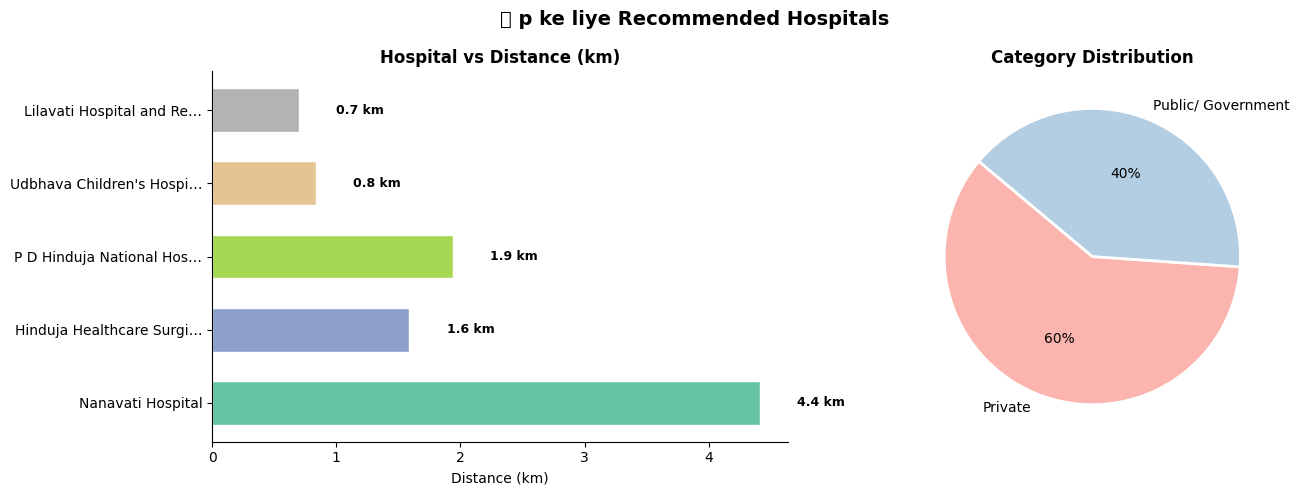

In [25]:
# Chart — sirf tab dikhao jab hospitals mile
if not result.empty:
    result['label'] = result['Hospital_Name'].apply(lambda x: x[:24] + '…' if len(x) > 24 else x)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'🏥 {user_name} ke liye Recommended Hospitals', fontsize=14, fontweight='bold')

    colors = plt.cm.Set2(np.linspace(0, 1, len(result)))

    # Left: Distance bar chart
    axes[0].barh(result['label'][::-1], result['distance_km'][::-1], color=colors, edgecolor='white', height=0.6)
    for bar, val in zip(axes[0].patches, result['distance_km'][::-1]):
        axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f} km', va='center', fontsize=9, fontweight='bold')
    axes[0].set_title('Hospital vs Distance (km)', fontweight='bold')
    axes[0].set_xlabel('Distance (km)')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Right: Category pie chart
    cat_counts = result['Hospital_Category'].value_counts()
    axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.0f%%', startangle=140,
                colors=plt.cm.Pastel1.colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Category Distribution', fontweight='bold')

    plt.tight_layout()
    plt.show()